In [1]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Deviding dataset into independent and dependent

In [ ]:
x = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]

In [ ]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


## Doing One Hot enCoding

In [ ]:
geograph = pd.get_dummies(x['Geography'],drop_first=True)
gender = pd.get_dummies(x['Gender'],drop_first=True)

In [ ]:
x = x.drop(['Geography','Gender'],axis=1)
pd.concat([x,geograph,gender],axis=1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
x_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  0.64259497,
         0.9687384 ,  1.61085707],
       [-1.31490297,  0.10961719, -1.031415  , ...,  0.64259497,
        -1.03227043,  0.49587037],
       [ 0.57162971,  0.30102557,  1.04473698, ...,  0.64259497,
         0.9687384 , -0.42478674],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.71888467],
       [-0.00566991, -0.46460796, -0.33936434, ...,  0.64259497,
         0.9687384 , -1.54507805],
       [-0.79945688, -0.84742473,  1.04473698, ...,  0.64259497,
        -1.03227043,  1.61255917]])

In [ ]:
x_train

array([[ 0.16958176, -0.46460796,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.10643166],
       [-2.30455945,  0.30102557, -1.37744033, ...,  0.64259497,
         0.9687384 , -0.74866447],
       [-1.19119591, -0.94312892, -1.031415  , ...,  0.64259497,
        -1.03227043,  1.48533467],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.41231994],
       [-0.62420521, -0.08179119,  1.39076231, ...,  0.64259497,
         0.9687384 ,  0.84432121],
       [-0.28401079,  0.87525072, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.32472465]])

## Start Creating ANN


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

## Initialize ANN

In [ ]:
classifier = Sequential()

## Adding Input Layer

In [ ]:
classifier.add(Dense(units=11,activation='relu'))

## Adding first hidden layer

In [ ]:
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.2))

## Adding second hidden layer

In [ ]:
classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.3))

## Adding Output Layer

In [ ]:
classifier.add(Dense(units=1,activation='sigmoid'))

In [ ]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=0,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

In [ ]:
model_history = classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=100,callbacks=early_stopping)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7892 - loss: 0.5066 - val_accuracy: 0.8360 - val_loss: 0.4012
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8332 - loss: 0.4178 - val_accuracy: 0.8247 - val_loss: 0.3979
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8365 - loss: 0.3911 - val_accuracy: 0.8368 - val_loss: 0.3950
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8184 - loss: 0.4156 - val_accuracy: 0.8413 - val_loss: 0.3857
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8286 - loss: 0.3987 - val_accuracy: 0.8395 - val_loss: 0.3895


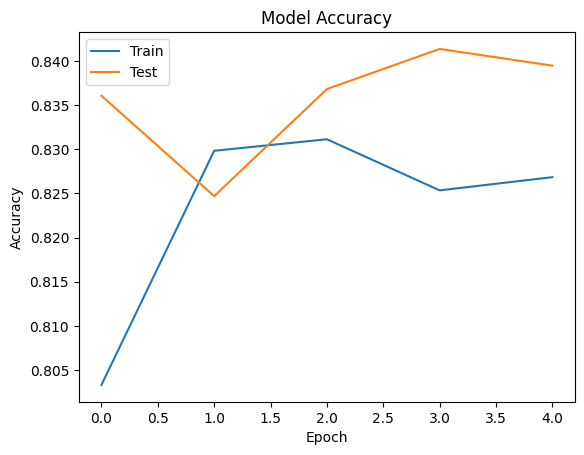

In [ ]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Test'],loc='upper left')
plt.show()

In [ ]:
#predicting test results
y_pred = classifier.predict(x_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm


array([[1566,   29],
       [ 258,  147]])

In [ ]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
score

0.8565

## Get the weights

In [ ]:
classifier.get_weights()

[array([[ 8.05012286e-02,  2.58264095e-01, -2.89970696e-01,
          7.32292607e-02, -1.29952297e-01,  1.47599190e-01,
         -2.74416417e-01,  1.28760353e-01, -1.62946954e-01,
          4.77162898e-02,  7.53780425e-01],
        [ 3.06389451e-01, -9.50852454e-01,  7.70033777e-01,
         -1.03244734e+00,  3.62366468e-01, -3.61837856e-02,
         -2.65460134e-01, -2.70894974e-01, -1.25318074e+00,
          5.48175573e-01, -5.52226841e-01],
        [ 6.13170788e-02,  2.41848499e-01, -8.01401436e-02,
         -2.08362684e-01, -3.78936589e-01,  2.25484297e-01,
          1.22967280e-01,  2.04937786e-01, -5.66367581e-02,
          2.27904677e-01, -4.17443545e-04],
        [ 3.95656586e-01, -4.77189034e-01, -1.55092821e-01,
         -9.75178033e-02, -7.85296112e-02, -6.69865429e-01,
         -2.66958307e-02, -1.19541562e+00,  3.86614531e-01,
          3.06185558e-02,  1.62169859e-01],
        [ 1.65448356e+00, -3.57845053e-02, -1.81685901e+00,
         -5.20695269e-01, -1.15504459e-01, -